# Taller de movilidad urbana: taxis y clima en Nueva York

**Caso de estudio:** viajes de NYC TLC Yellow Taxi durante enero de 2024.

En este taller construiremos un flujo reproducible: adquisición, inspección, auditoría de calidad, enriquecimiento por zonas, agregación temporal, integración con clima y análisis exploratorio. No buscamos demostrar causalidad, sino aprender a formular y comprobar preguntas con datos reales.

## Objetivos

Al finalizar podrás:

- construir y validar una URL de datos abiertos;
- inspeccionar estructura, tipos y faltantes antes de analizar;
- convertir reglas de calidad en una tabla de auditoría;
- enriquecer viajes mediante uniones `many_to_one`;
- agregar pickups por zona y hora sin sesgar la serie temporal;
- convertir observaciones meteorológicas de UTC a `America/New_York`;
- comunicar patrones y límites de un análisis exploratorio.

> **Pregunta guía:** ¿cómo varían los pickups de Yellow Taxi por lugar y hora, y qué relación exploratoria muestran con temperatura y precipitación?

## Ficha de fuentes

| Fuente | Recurso usado | Papel en el taller |
|---|---|---|
| [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) | Yellow Taxi, enero de 2024 (`yellow_tripdata_2024-01.parquet`) | fecha/hora, zonas, distancia, pasajeros e importes de viajes reportados |
| NYC TLC | [Taxi Zone Lookup](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv) | traduce `LocationID` a borough, zona y `service_zone` |
| NYC TLC | [Taxi Zone Shapefile](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip) | geometrías para la extensión espacial opcional |
| [NOAA GHCNh](https://www.ncei.noaa.gov/products/global-historical-climatology-network-hourly) | estación `USW00094728`, año 2024 | observaciones de clima con marcas temporales UTC |

**Periodo común:** enero de 2024 en hora local de Nueva York. Los archivos se leen desde sus URL o desde un directorio temporal; este notebook no guarda datasets en el repositorio. Consulta la documentación y licencias de cada proveedor antes de reutilizar los datos.

## 1. Preparación y modo de ejecución

En Colab normalmente basta con ejecutar los imports. Si falta el motor Parquet, descomenta la instalación. La extensión espacial se instala solo si se desea ejecutar esa sección.

In [1]:
# Instalación opcional para Google Colab/Jupyter (descomentar si hace falta):
# %pip install -q pyarrow
# %pip install -q geopandas folium requests

from io import StringIO
import tempfile
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# True: primera semana de enero; False: todo enero. No hay muestreo aleatorio.
MODO_CLASE = False
INICIO_MES = pd.Timestamp("2024-01-01")
FIN_MES = pd.Timestamp("2024-02-01")
FIN_ANALISIS = pd.Timestamp("2024-01-08") if MODO_CLASE else FIN_MES
ZONA_HORARIA = "America/New_York"

print(f"Ventana: {INICIO_MES} hasta {FIN_ANALISIS} (fin no incluido)")

Ventana: 2024-01-01 00:00:00 hasta 2024-02-01 00:00:00 (fin no incluido)


`MODO_CLASE` limita la lectura mediante un filtro temporal de Parquet cuando el motor lo permite. La selección es una semana completa y determinista, no una muestra aleatoria: así preservamos horas consecutivas y el flujo de agregación. En modo completo, la misma lógica procesa todo enero.

## 2. URL validada y carga reproducible

In [3]:
def construir_url_tlc(tipo, anio, mes):
    """Construye una URL TLC válida para un tipo, año y mes."""
    prefijos = {
        "yellow": "yellow_tripdata",
        "green": "green_tripdata",
        "fhv": "fhv_tripdata",
        "fhvhv": "fhvhv_tripdata",
    }
    if tipo not in prefijos:
        opciones = ", ".join(prefijos)
        raise ValueError(f"tipo debe ser uno de: {opciones}")
    if isinstance(anio, bool) or not isinstance(anio, (int, np.integer)) or not 2009 <= anio <= 2100:
        raise ValueError("anio debe ser un entero entre 2009 y 2100")
    if isinstance(mes, bool) or not isinstance(mes, (int, np.integer)) or not 1 <= mes <= 12:
        raise ValueError("mes debe ser un entero entre 1 y 12")
    archivo = f"{prefijos[tipo]}_{anio}-{mes:02d}.parquet"
    return f"https://d37ci6vzurychx.cloudfront.net/trip-data/{archivo}"

URL_VIAJES = construir_url_tlc("yellow", 2024, 1)
URL_ZONAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
URL_GEOMETRIAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
URL_CLIMA = (
    "https://www.ncei.noaa.gov/oa/global-historical-climatology-network/"
    "hourly/access/by-year/2024/psv/GHCNh_USW00094728_2024.psv"
)
print(URL_VIAJES)

https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet


In [4]:
COLUMNAS_VIAJES = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "PULocationID",
    "DOLocationID", "fare_amount", "total_amount",
]
filtros = [
    ("tpep_pickup_datetime", ">=", INICIO_MES.to_pydatetime()),
    ("tpep_pickup_datetime", "<", FIN_ANALISIS.to_pydatetime()),
]

# PyArrow aplica el filtro por fecha al leer los grupos de filas compatibles.
viajes_originales = pd.read_parquet(
    URL_VIAJES, columns=COLUMNAS_VIAJES, filters=filtros, engine="pyarrow"
)
print(f"Viajes cargados: {len(viajes_originales):,}")

Viajes cargados: 2,964,606


### Pregunta breve

¿Por qué una semana consecutiva es preferible a una muestra aleatoria si queremos comparar horas y días? Escribe una hipótesis antes de continuar.

<details><summary>Ver respuesta orientativa</summary>Una muestra aleatoria puede dejar horas incompletas y alterar sus conteos. Una ventana consecutiva conserva el orden, los ciclos diarios y el denominador temporal, aunque no necesariamente representa el mes completo.</details>

## 3. Inspección antes de limpiar

No debemos decidir reglas sin conocer el esquema. Observa dimensiones, ejemplos, tipos y faltantes.

In [5]:
print("Shape:", viajes_originales.shape)
display(viajes_originales.head())
print("\nInfo:")
viajes_originales.info()
print("\nTipos:")
display(viajes_originales.dtypes.rename("dtype").to_frame())

faltantes = (
    viajes_originales.isna().sum().rename("n_faltantes").to_frame()
    .assign(porcentaje=lambda x: 100 * x["n_faltantes"] / len(viajes_originales))
    .sort_values("porcentaje", ascending=False)
)
display(faltantes)

Shape: (2964606, 8)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,186,79,17.7,22.70
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,140,236,10.0,18.75
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,236,79,23.3,31.30
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,79,211,10.0,17.00
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,211,148,7.9,16.10



Info:
<class 'pandas.DataFrame'>
RangeIndex: 2964606 entries, 0 to 2964605
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   PULocationID           int32         
 5   DOLocationID           int32         
 6   fare_amount            float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(4), int32(2)
memory usage: 158.3 MB

Tipos:


,dtype
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
PULocationID,int32
DOLocationID,int32
fare_amount,float64
total_amount,float64


,n_faltantes,porcentaje
passenger_count,140162,4.727846
tpep_pickup_datetime,0,0.000000
tpep_dropoff_datetime,0,0.000000
trip_distance,0,0.000000
PULocationID,0,0.000000
DOLocationID,0,0.000000
fare_amount,0,0.000000
total_amount,0,0.000000


**Observa:** `passenger_count` puede faltar por la forma de reporte. Su ausencia se conserva y no invalida automáticamente un viaje. Solo marcaremos como problemáticos los valores presentes fuera de un intervalo operativo razonable.

## 4. Calidad y auditoría

Las reglas siguientes son criterios analíticos, no verdades universales. Distancia máxima de 100 millas, hasta 8 pasajeros e importes menores a USD 1,000 son umbrales conservadores para detectar registros extremos o inválidos. Cada regla queda en una columna booleana.

In [6]:
calidad = viajes_originales.copy()
calidad["duracion_min"] = (
    calidad["tpep_dropoff_datetime"] - calidad["tpep_pickup_datetime"]
).dt.total_seconds() / 60

calidad["ok_pickup"] = calidad["tpep_pickup_datetime"].notna() & calidad["tpep_pickup_datetime"].between(INICIO_MES, FIN_ANALISIS, inclusive="left")
calidad["ok_dropoff"] = calidad["tpep_dropoff_datetime"].notna()
calidad["ok_duracion"] = calidad["duracion_min"].gt(0) & calidad["duracion_min"].le(24 * 60)
calidad["ok_distancia"] = calidad["trip_distance"].between(0, 100, inclusive="both")
calidad["ok_id_pickup_presente"] = calidad["PULocationID"].notna()
calidad["ok_id_dropoff_presente"] = calidad["DOLocationID"].notna()
calidad["ok_importes"] = (
    calidad["fare_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].ge(calidad["fare_amount"])
)
calidad["ok_pasajeros"] = calidad["passenger_count"].isna() | calidad["passenger_count"].between(0, 8, inclusive="both")

REGLAS = [c for c in calidad.columns if c.startswith("ok_")]
calidad["registro_valido"] = calidad[REGLAS].all(axis=1)
auditoria = pd.DataFrame({
    "regla": REGLAS,
    "cumplen": [int(calidad[c].sum()) for c in REGLAS],
    "incumplen": [int((~calidad[c]).sum()) for c in REGLAS],
})
auditoria["porcentaje_incumple"] = 100 * auditoria["incumplen"] / len(calidad)
display(auditoria.sort_values("porcentaje_incumple", ascending=False))

,regla,cumplen,incumplen,porcentaje_incumple
6,ok_importes,2927032,37574,1.267420
2,ok_duracion,2963720,886,0.029886
3,ok_distancia,2964547,59,0.001990
7,ok_pasajeros,2964605,1,0.000034
0,ok_pickup,2964606,0,0.000000
1,ok_dropoff,2964606,0,0.000000
5,ok_id_dropoff_presente,2964606,0,0.000000
4,ok_id_pickup_presente,2964606,0,0.000000


In [7]:
# Se mantienen por separado para no borrar silenciosamente información.
viajes_rechazados = calidad.loc[~calidad["registro_valido"]].copy()
viajes_validos = calidad.loc[calidad["registro_valido"]].copy()
print(f"Válidos: {len(viajes_validos):,} | Rechazados: {len(viajes_rechazados):,}")
display(viajes_rechazados[COLUMNAS_VIAJES + ["duracion_min"] + REGLAS].head())

Válidos: 2,926,101 | Rechazados: 38,505


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount,duracion_min,ok_pickup,ok_dropoff,ok_duracion,ok_distancia,ok_id_pickup_presente,ok_id_dropoff_presente,ok_importes,ok_pasajeros
23,2024-01-01 00:14:29,2024-01-01 00:14:29,1.0,0.00,236,264,3.0,8.00,0.000000,True,True,False,True,True,True,True,True
99,2024-01-01 00:18:24,2024-01-01 00:30:39,1.0,2.16,249,232,-13.5,-18.50,12.250000,True,True,True,True,True,True,False,True
504,2024-01-01 00:04:00,2024-01-01 00:04:44,1.0,0.01,63,63,-31.5,-34.25,0.733333,True,True,True,True,True,True,False,True
534,2024-01-01 00:41:42,2024-01-01 00:46:00,1.0,0.47,249,113,-5.8,-10.80,4.300000,True,True,True,True,True,True,False,True
550,2024-01-01 00:42:02,2024-01-01 01:14:33,1.0,5.48,107,61,-33.1,-38.10,32.516667,True,True,True,True,True,True,False,True


### Ejercicio 1: sensibilidad de una regla

Calcula cuántos viajes quedarían fuera si la distancia máxima fuese 50 millas, sin modificar `viajes_validos`.

In [8]:
# Tu respuesta:
# fuera_con_umbral_50 = ...

<details><summary>Ver solución</summary>

```python
fuera_con_umbral_50 = (~calidad["trip_distance"].between(0, 50)).sum()
print(fuera_con_umbral_50)
```

Conviene comparar este resultado con `ok_distancia` y justificar el umbral con conocimiento del dominio.
</details>

## 5. Enriquecimiento con zonas

### Objetivo

La tabla de viajes identifica el origen mediante `PULocationID` y el destino mediante `DOLocationID`. Estos códigos son útiles para relacionar tablas, pero no permiten interpretar directamente dónde comenzó o terminó un viaje.

En esta sección agregaremos a cada viaje el nombre de la zona, el borough y la clasificación de servicio tanto del origen como del destino. Conceptualmente:

```text
PULocationID = 161
        ↓
pickup_zone = Midtown Center
pickup_borough = Manhattan
pickup_service_zone = Yellow Zone
```

El enriquecimiento no cambia la unidad de observación: cada fila continúa representando un viaje Yellow Taxi reportado. Solo agrega contexto geográfico a sus identificadores.

### 5.1. El catálogo de zonas

`taxi_zone_lookup.csv` es un **catálogo de correspondencias** publicado por NYC TLC. No contiene viajes: contiene una descripción por `LocationID`.

| Columna | Significado |
|---|---|
| `LocationID` | Identificador numérico de la zona TLC |
| `Borough` | Distrito amplio, como Manhattan, Queens o Brooklyn |
| `Zone` | Nombre específico de la zona TLC |
| `service_zone` | Clasificación operativa, como `Yellow Zone`, `Boro Zone` o `Airports` |

Para que el catálogo pueda representar el lado **uno** de una unión, `LocationID` debe ser único.

In [9]:
zonas = pd.read_csv(URL_ZONAS)
display(zonas.head())
print("Cantidad de zonas:", len(zonas))
print("LocationID es único:", zonas["LocationID"].is_unique)

if zonas["LocationID"].duplicated().any():
    raise ValueError("Taxi Zone Lookup contiene LocationID duplicados")

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Cantidad de zonas: 265
LocationID es único: True


### 5.2. Un catálogo, dos roles

Cada viaje consulta el mismo catálogo desde dos papeles diferentes:

```text
PULocationID → zona de origen o pickup
DOLocationID → zona de destino o dropoff
```

Por eso creamos `zonas_pickup` y `zonas_dropoff`. No son dos catálogos distintos ni duplican los viajes: son dos versiones del mismo catálogo con nombres que explicitan el rol de sus columnas.

| Origen | Destino |
|---|---|
| `pickup_zone` | `dropoff_zone` |
| `pickup_borough` | `dropoff_borough` |
| `pickup_service_zone` | `dropoff_service_zone` |

Renombrar antes de unir evita nombres ambiguos como `Zone_x` y `Zone_y`. `DataFrame.rename()` devuelve estas versiones adaptadas sin modificar `zonas`.

In [10]:
zonas_pickup = zonas.rename(columns={
    "LocationID": "PULocationID", "Borough": "pickup_borough",
    "Zone": "pickup_zone", "service_zone": "pickup_service_zone",
})
zonas_dropoff = zonas.rename(columns={
    "LocationID": "DOLocationID", "Borough": "dropoff_borough",
    "Zone": "dropoff_zone", "service_zone": "dropoff_service_zone",
})

display(zonas_pickup.head(2))
display(zonas_dropoff.head(2))

,PULocationID,pickup_borough,pickup_zone,pickup_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


### 5.3. Cardinalidad `many_to_one`

La relación esperada es **muchos viajes → una descripción de zona**. Un mismo `PULocationID` o `DOLocationID` puede aparecer en miles de viajes, pero cada identificador debe aparecer como máximo una vez en el catálogo correspondiente.

`validate="many_to_one"` hace que pandas compruebe esta condición durante la unión. Si el catálogo tuviera dos filas para `LocationID = 161`, tres viajes con ese identificador producirían seis filas:

```text
3 viajes × 2 coincidencias en el catálogo = 6 filas
```

Esa multiplicación inflaría conteos, importes, promedios y mapas. La validación detiene el proceso con un error en lugar de producir silenciosamente un resultado incorrecto. También ayuda a detectar catálogos repetidos, mezcla de versiones o descripciones contradictorias para un mismo ID.

### 5.4. Dos uniones izquierdas

Primero agregamos los atributos del origen y después los del destino. `how="left"` conserva todos los viajes válidos. Si un ID no aparece en el catálogo, el viaje permanece y sus atributos geográficos quedan como `NaN`, lo que permite auditar la falta de correspondencia en vez de eliminarla silenciosamente.

In [11]:
viajes_zonas = (
    viajes_validos.merge(zonas_pickup, on="PULocationID", how="left", validate="many_to_one")
    .merge(zonas_dropoff, on="DOLocationID", how="left", validate="many_to_one")
)

### 5.5. Controles posteriores e interpretación

Después de unir comprobamos dos propiedades diferentes:

1. **Conservación de filas:** la cantidad de viajes no debe cambiar.
2. **Cobertura del catálogo:** contamos los viajes cuyo ID no encontró nombre de zona.

`many_to_one` no garantiza cobertura completa ni detecta viajes duplicados, IDs faltantes, nombres incorrectos en una fila única o el uso de la clave equivocada. Por eso se complementa con estos controles y con la revisión semántica de las columnas obtenidas.

In [12]:
assert len(viajes_zonas) == len(viajes_validos), "La unión cambió el número de viajes"

sin_nombre_pickup = viajes_zonas["pickup_zone"].isna().sum()
sin_nombre_dropoff = viajes_zonas["dropoff_zone"].isna().sum()
print("Viajes antes y después:", len(viajes_validos), len(viajes_zonas))
print("Sin zona pickup:", sin_nombre_pickup, "| Sin zona dropoff:", sin_nombre_dropoff)

COLUMNAS_ZONA = [
    "PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone",
    "DOLocationID", "dropoff_borough", "dropoff_zone", "dropoff_service_zone",
]
display(viajes_zonas[COLUMNAS_ZONA].head())

Viajes antes y después: 2926101 2926101
Sin zona pickup: 10177 | Sin zona dropoff: 15295


,PULocationID,pickup_borough,pickup_zone,pickup_service_zone,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,186,Manhattan,Penn Station/Madison Sq West,Yellow Zone,79,Manhattan,East Village,Yellow Zone
1,140,Manhattan,Lenox Hill East,Yellow Zone,236,Manhattan,Upper East Side North,Yellow Zone
2,236,Manhattan,Upper East Side North,Yellow Zone,79,Manhattan,East Village,Yellow Zone
3,79,Manhattan,East Village,Yellow Zone,211,Manhattan,SoHo,Yellow Zone
4,211,Manhattan,SoHo,Yellow Zone,148,Manhattan,Lower East Side,Yellow Zone


### Resultado de la sección

Cada fila sigue representando un viaje, pero ahora permite interpretar tanto su origen como su destino. Las zonas son áreas geográficas agregadas definidas por TLC: no indican una dirección ni una coordenada exacta, y el enriquecimiento no agrega demanda total, solicitudes no atendidas ni vehículos disponibles.

### Pregunta breve

¿Qué ocurriría si `LocationID = 161` apareciera dos veces en el catálogo y no utilizáramos `validate="many_to_one"`?

<details><summary>Ver respuesta orientativa</summary>Cada viaje con ese identificador encontraría dos coincidencias y aparecería dos veces en el resultado. Los conteos y agregaciones posteriores quedarían inflados. Con `validate="many_to_one"`, pandas detecta que el lado del catálogo no es único y detiene la unión.</details>

## 6. Agregación zona-hora de pickups

Los timestamps TLC se interpretan como hora local. En enero de 2024 no hay transición de horario de verano, pero explicitar la zona horaria evita una unión ambigua con NOAA.

In [13]:
viajes_zonas["pickup_hora"] = (
    viajes_zonas["tpep_pickup_datetime"]
    .dt.tz_localize(ZONA_HORARIA, ambiguous="raise", nonexistent="raise")
    .dt.floor("h")
)
pickups_zona_hora = (
    viajes_zonas.groupby(
        ["pickup_hora", "PULocationID", "pickup_borough", "pickup_zone"],
        observed=True, dropna=False,
    )
    .size().rename("pickups").reset_index()
)
assert pickups_zona_hora.duplicated(["pickup_hora", "PULocationID"]).sum() == 0
display(pickups_zona_hora.head())

,pickup_hora,PULocationID,pickup_borough,pickup_zone,pickups
0,2024-01-01 00:00:00-05:00,4,Manhattan,Alphabet City,24
1,2024-01-01 00:00:00-05:00,7,Queens,Astoria,4
2,2024-01-01 00:00:00-05:00,9,Queens,Auburndale,1
3,2024-01-01 00:00:00-05:00,10,Queens,Baisley Park,6
4,2024-01-01 00:00:00-05:00,12,Manhattan,Battery Park,4


## 7. Clima: UTC, hora local y resumen horario

GHCNh puede contener varias observaciones dentro de una hora. Seleccionaremos variables numéricas, convertiremos valores no numéricos a faltantes y resumiremos a una fila por hora. Temperatura usa media; precipitación usa suma con `min_count=1` para no convertir una hora totalmente faltante en cero.

In [14]:
COLUMNAS_CLIMA = [
    "STATION", "Station_name", "DATE", "temperature",
    "relative_humidity", "wind_speed", "precipitation", "visibility",
]
with urlopen(URL_CLIMA) as respuesta:
    texto_clima = respuesta.read().decode("utf-8")
clima_bruto = pd.read_csv(StringIO(texto_clima), sep="|", usecols=COLUMNAS_CLIMA, low_memory=False)
assert clima_bruto["STATION"].astype(str).eq("USW00094728").all()
print("Observaciones meteorológicas cargadas:", len(clima_bruto))

Observaciones meteorológicas cargadas: 11222


In [15]:
clima = clima_bruto.copy()
clima["fecha_utc"] = pd.to_datetime(clima["DATE"], utc=True, errors="coerce")
clima["fecha_ny"] = clima["fecha_utc"].dt.tz_convert(ZONA_HORARIA)
inicio_local = INICIO_MES.tz_localize(ZONA_HORARIA)
fin_local = FIN_ANALISIS.tz_localize(ZONA_HORARIA)
clima = clima.loc[clima["fecha_ny"].between(inicio_local, fin_local, inclusive="left")].copy()

VARIABLES_CLIMA = ["temperature", "relative_humidity", "wind_speed", "precipitation", "visibility"]
clima[VARIABLES_CLIMA] = clima[VARIABLES_CLIMA].apply(pd.to_numeric, errors="coerce")
clima["hora"] = clima["fecha_ny"].dt.floor("h")
clima_horario = (
    clima.groupby("hora", as_index=False)
    .agg(
        temperatura_c=("temperature", "mean"),
        humedad_relativa=("relative_humidity", "mean"),
        viento=("wind_speed", "mean"),
        precipitacion_mm=("precipitation", lambda s: s.sum(min_count=1)),
        visibilidad=("visibility", "mean"),
        observaciones=("fecha_ny", "size"),
    )
)
if clima_horario["hora"].duplicated().any():
    raise ValueError("El resumen climático no es único por hora")
display(clima_horario.head())

,hora,temperatura_c,humedad_relativa,viento,precipitacion_mm,visibilidad,observaciones
0,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,0.0,16.093,1
1,2024-01-01 01:00:00-05:00,5.6,58.0,2.1,0.0,16.093,1
2,2024-01-01 02:00:00-05:00,5.0,60.0,0.0,0.0,16.093,1
3,2024-01-01 03:00:00-05:00,5.0,62.0,1.5,0.0,16.093,1
4,2024-01-01 04:00:00-05:00,4.4,68.0,0.0,0.0,16.093,1


### Ejercicio 2: cobertura temporal

Compara las horas esperadas de la ventana con las horas observadas en `clima_horario`. ¿Hay huecos?

In [16]:
# Tu respuesta:
# horas_esperadas = ...
# horas_sin_clima = ...

<details><summary>Ver solución</summary>

```python
horas_esperadas = pd.date_range(inicio_local, fin_local, freq="h", inclusive="left")
horas_sin_clima = horas_esperadas.difference(clima_horario["hora"])
print("Horas esperadas:", len(horas_esperadas))
print("Horas sin observación:", len(horas_sin_clima))
display(horas_sin_clima[:10])
```
</details>

## 8. Unión zona-hora con clima

Cada fila zona-hora debe encontrar como máximo una fila climática. La unión izquierda conserva los pickups aunque el clima falte.

In [17]:
zona_hora_clima = pickups_zona_hora.merge(
    clima_horario, left_on="pickup_hora", right_on="hora",
    how="left", validate="many_to_one", indicator=True,
)
assert len(zona_hora_clima) == len(pickups_zona_hora), "La unión alteró la cardinalidad izquierda"
auditoria_union = zona_hora_clima["_merge"].value_counts(dropna=False).rename_axis("resultado").to_frame("filas")
display(auditoria_union)
zona_hora_clima = zona_hora_clima.drop(columns="_merge")

,filas
resultado,
both,77335
left_only,131
right_only,0


### ¿Por qué el clima queda repetido por zona?

La unidad de `zona_hora_clima` es **una zona en una hora**. En cambio, `clima_horario` contiene una sola observación por hora. Cuando esa observación se une con varias zonas de la misma hora, pandas la copia en cada fila zona-hora.

Ejemplo conceptual:

| zona | hora | pickups | temperatura |
|---|---|---:|---:|
| A | 08:00 | 20 | 5 °C |
| B | 08:00 | 35 | 5 °C |
| C | 08:00 | 15 | 5 °C |

Los tres valores de `5 °C` no son mediciones diferentes: son la misma observación meteorológica replicada por la unión `many_to_one`. Esta repetición es intencional, no un duplicado accidental. Además, NOAA representa una estación meteorológica; no estamos estimando un clima diferente para cada zona.

## 9. Análisis exploratorio con pandas y matplotlib

Lee cada gráfico como evidencia descriptiva. Pregunta siempre: ¿qué unidad representa?, ¿qué filtros se aplicaron?, ¿qué explicación alternativa existe?

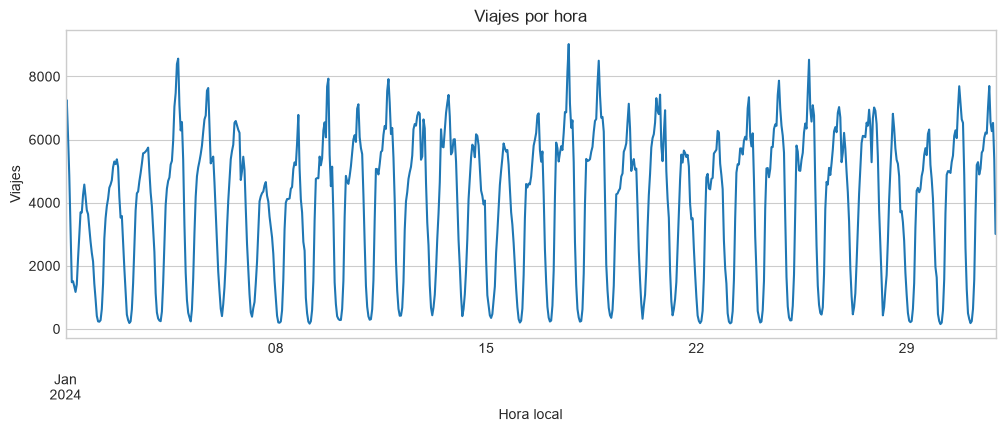

In [18]:
viajes_por_hora = viajes_zonas.set_index("pickup_hora").resample("h").size()
ax = viajes_por_hora.plot(figsize=(12, 4), color="#1f77b4", linewidth=1.5)
ax.set(title="Viajes por hora", xlabel="Hora local", ylabel="Viajes")
plt.show()

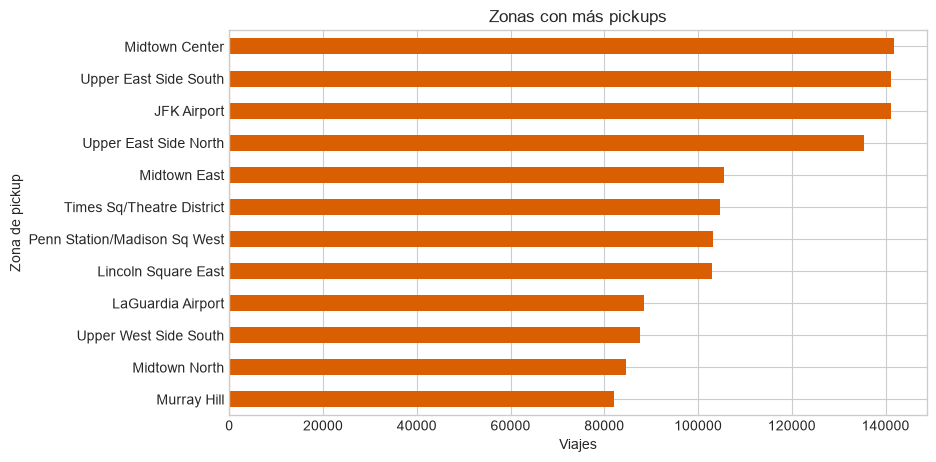

,pickups
pickup_zone,
Midtown Center,141714
Upper East Side South,141237
JFK Airport,141107
Upper East Side North,135303
Midtown East,105440
Times Sq/Theatre District,104590
Penn Station/Madison Sq West,103254
Lincoln Square East,102960
LaGuardia Airport,88556


In [19]:
top_zonas = viajes_zonas["pickup_zone"].value_counts().head(12).sort_values()
ax = top_zonas.plot.barh(figsize=(9, 5), color="#d95f02")
ax.set(title="Zonas con más pickups", xlabel="Viajes", ylabel="Zona de pickup")
plt.show()
display(top_zonas.sort_values(ascending=False).rename("pickups").to_frame())

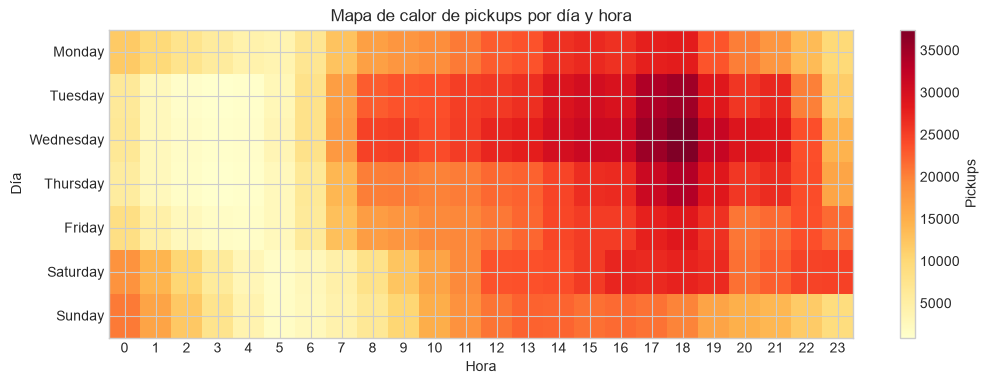

In [20]:
patron = viajes_zonas.assign(
    dia=viajes_zonas["pickup_hora"].dt.day_name(),
    hora_dia=viajes_zonas["pickup_hora"].dt.hour,
).pivot_table(index="dia", columns="hora_dia", values="PULocationID", aggfunc="size", fill_value=0)
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
patron = patron.reindex([d for d in orden_dias if d in patron.index])
fig, ax = plt.subplots(figsize=(12, 4))
imagen = ax.imshow(patron, aspect="auto", cmap="YlOrRd")
ax.set(title="Mapa de calor de pickups por día y hora", xlabel="Hora", ylabel="Día")
ax.set_xticks(range(24), labels=range(24))
ax.set_yticks(range(len(patron.index)), labels=patron.index)
fig.colorbar(imagen, ax=ax, label="Pickups")
plt.show()

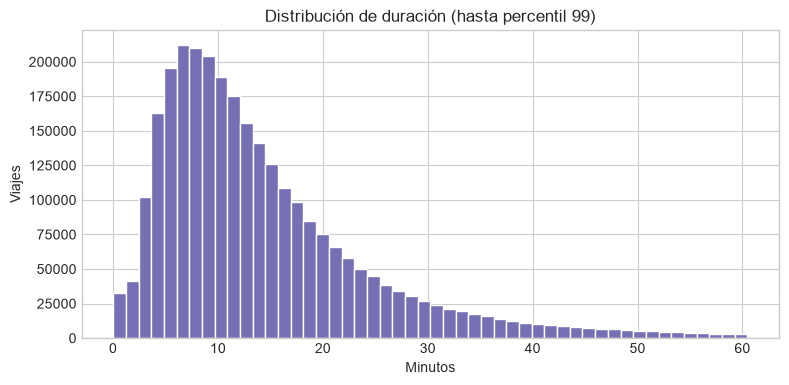

Percentil 99 mostrado: 60.5 minutos


In [21]:
limite_99 = viajes_validos["duracion_min"].quantile(0.99)
ax = viajes_validos.loc[viajes_validos["duracion_min"] <= limite_99, "duracion_min"].plot.hist(
    bins=50, figsize=(9, 4), color="#7570b3", edgecolor="white"
)
ax.set(title="Distribución de duración (hasta percentil 99)", xlabel="Minutos", ylabel="Viajes")
plt.show()
print("Percentil 99 mostrado:", round(limite_99, 1), "minutos")

### 9.1. De zona-hora a una observación por hora

Para comparar la actividad total de taxis con el clima debemos volver de la unidad **zona-hora** a la unidad **hora**. En el ejemplo anterior:

```text
pickups = 20 + 35 + 15 = 70
temperatura = 5 °C
```

Por eso usamos operaciones diferentes:

- `sum` para `pickups`, porque cada zona aporta viajes distintos;
- `first` para temperatura y precipitación, porque cada fila contiene una copia del mismo clima horario.

Sumar la temperatura produciría `5 + 5 + 5 = 15 °C`, un valor sin interpretación física. El uso de `first` requiere comprobar antes que una misma hora no contenga valores climáticos diferentes entre zonas.

Consistencia climática por hora: OK


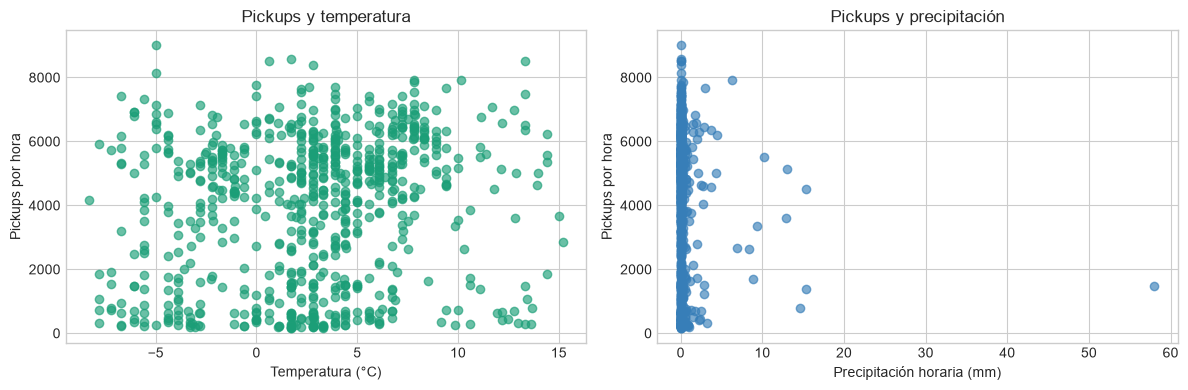

,pickups,temperatura_c,precipitacion_mm
pickups,1.000,0.158,-0.054
temperatura_c,0.158,1.000,0.193
precipitacion_mm,-0.054,0.193,1.000


In [22]:
# Verificamos el supuesto necesario para conservar una sola copia con 'first'.
variables_clima_repetidas = ["temperatura_c", "precipitacion_mm"]
consistencia_clima = (
    zona_hora_clima
    .groupby("pickup_hora")[variables_clima_repetidas]
    .nunique(dropna=False)
)
assert consistencia_clima.le(1).all().all(), (
    "Una misma hora contiene valores climáticos diferentes entre zonas"
)
print("Consistencia climática por hora: OK")

# El clima está repetido por zona; volvemos a una observación por hora.
comparacion_horaria = (
    zona_hora_clima.groupby("pickup_hora", as_index=False)
    .agg(
        pickups=("pickups", "sum"),
        temperatura_c=("temperatura_c", "first"),
        precipitacion_mm=("precipitacion_mm", "first"),
    )
)
assert not comparacion_horaria["pickup_hora"].duplicated().any()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(comparacion_horaria["temperatura_c"], comparacion_horaria["pickups"], alpha=0.65, color="#1b9e77")
axes[0].set(xlabel="Temperatura (°C)", ylabel="Pickups por hora", title="Pickups y temperatura")
axes[1].scatter(comparacion_horaria["precipitacion_mm"], comparacion_horaria["pickups"], alpha=0.65, color="#377eb8")
axes[1].set(xlabel="Precipitación horaria (mm)", ylabel="Pickups por hora", title="Pickups y precipitación")
plt.tight_layout()
plt.show()
display(comparacion_horaria[["pickups", "temperatura_c", "precipitacion_mm"]].corr().round(3))

### Pregunta breve

¿Qué ocurriría si sumáramos la temperatura después de haberla replicado por zona?

<details><summary>Ver respuesta orientativa</summary>La misma observación se contabilizaría varias veces y produciría una temperatura sin interpretación física. Los pickups sí se suman porque cada zona aporta viajes diferentes; el clima se conserva una sola vez porque es el mismo valor replicado.</details>

### Ejercicio 3: interpretar sin exagerar

Escribe dos observaciones de los gráficos y una explicación alternativa. Evita frases causales como “la lluvia provoca...”.

**Tu respuesta:**

1. ...
2. ...
3. Explicación alternativa: ...

<details><summary>Ver pauta de solución</summary>Una respuesta sólida identifica dirección, magnitud o franjas horarias, menciona la ventana analizada y reconoce factores de confusión como hora pico, día de semana, aeropuerto, feriados o disponibilidad de taxis. Una correlación horaria no permite atribuir causalidad al clima.</details>

## 10. Exportar el producto fuera del repositorio

Antes de exportar comprobamos la clave, ordenamos el producto y usamos el directorio temporal del sistema. El nombre distingue el modo de clase del mes completo para no declarar una cobertura que no fue procesada.

In [23]:
producto = zona_hora_clima.sort_values(["pickup_hora", "PULocationID"]).copy()
if producto.duplicated(["pickup_hora", "PULocationID"]).any():
    raise ValueError("La clave zona-hora no es única")

alcance = "primera_semana_enero_2024" if MODO_CLASE else "enero_2024"
ruta_producto = Path(tempfile.gettempdir()) / f"zona_hora_{alcance}.parquet"
producto.to_parquet(ruta_producto, index=False)
print("Producto temporal:", ruta_producto)
print("Unidad: zona de origen-hora local | Zona horaria:", ZONA_HORARIA)

Producto temporal: C:\Users\User\AppData\Local\Temp\zona_hora_enero_2024.parquet
Unidad: zona de origen-hora local | Zona horaria: America/New_York


## 11. Extensión espacial opcional

Esta celda descarga el ZIP del shapefile a un directorio temporal, extrae juntos sus componentes (`.shp`, `.dbf`, `.shx`, `.prj`) y construye un mapa Folium. La extracción explícita evita depender de que el backend geoespacial admita rutas virtuales `zip://`; al finalizar, el directorio temporal se elimina y no deja geometrías en el repositorio. Si `geopandas`, `folium` o `requests` no están instalados, informa exactamente cómo habilitar la sección y el resto del taller sigue siendo utilizable.

In [24]:
try:
    import folium
    import geopandas as gpd
    import requests
    import zipfile
except ModuleNotFoundError as error:
    print(
        f"Sección espacial omitida: falta '{error.name}'. "
        "Descomenta `%pip install -q geopandas folium requests`, reinicia si es necesario y vuelve a ejecutar."
    )
else:
    with tempfile.TemporaryDirectory() as directorio_base:
        ruta_zip = Path(directorio_base) / "taxi_zones.zip"
        respuesta = requests.get(URL_GEOMETRIAS, timeout=60)
        respuesta.raise_for_status()
        ruta_zip.write_bytes(respuesta.content)
        if not zipfile.is_zipfile(ruta_zip):
            raise zipfile.BadZipFile("La descarga de zonas TLC no es un archivo ZIP válido")

        directorio_extraido = Path(directorio_base) / "taxi_zones_extraido"
        directorio_extraido.mkdir()
        with zipfile.ZipFile(ruta_zip) as archivo_zip:
            archivo_zip.extractall(directorio_extraido)

        archivos_shp = sorted(directorio_extraido.rglob("*.shp"))
        if not archivos_shp:
            raise FileNotFoundError("No se encontró un archivo .shp dentro del ZIP de zonas TLC")
        ruta_shp = next((ruta for ruta in archivos_shp if ruta.name == "taxi_zones.shp"), archivos_shp[0])
        geo_zonas = gpd.read_file(ruta_shp).to_crs(epsg=4326)

    pickups_mapa = viajes_zonas["PULocationID"].value_counts().rename("pickups").reset_index()
    geo_zonas["LocationID"] = pd.to_numeric(geo_zonas["LocationID"])
    geo_mapa = geo_zonas.merge(pickups_mapa, left_on="LocationID", right_on="PULocationID", how="left", validate="one_to_one")
    geo_mapa["pickups"] = geo_mapa["pickups"].fillna(0)
    min_x, min_y, max_x, max_y = geo_mapa.total_bounds
    centro = [(min_y + max_y) / 2, (min_x + max_x) / 2]
    mapa = folium.Map(location=centro, zoom_start=10, tiles="CartoDB positron")
    folium.Choropleth(
        geo_data=geo_mapa, data=geo_mapa, columns=["LocationID", "pickups"],
        key_on="feature.properties.LocationID", fill_color="YlOrRd",
        fill_opacity=0.7, line_opacity=0.3, legend_name="Pickups",
    ).add_to(mapa)
    folium.GeoJson(
        geo_mapa, style_function=lambda _: {"fillOpacity": 0, "weight": 0},
        tooltip=folium.GeoJsonTooltip(fields=["zone", "borough", "pickups"], aliases=["Zona", "Borough", "Pickups"]),
    ).add_to(mapa)
    display(mapa)

## 12. Conclusiones y límites

**Qué construimos**

- un proceso reproducible para enero de 2024, escalable de una semana al mes;
- una auditoría que hace visibles los criterios de exclusión;
- una tabla zona-hora enriquecida con clima mediante cardinalidad comprobada;
- visualizaciones temporales, espaciales y de asociación exploratoria.

**Límites que deben acompañar cualquier conclusión**

- Los registros son **viajes reportados de Yellow Taxi**, no demanda total, viajes no atendidos ni toda la movilidad de Nueva York.
- Una sola estación, `USW00094728`, no representa toda la variación meteorológica espacial de la ciudad.
- La cobertura y frecuencia de GHCNh pueden variar; resumir precipitación subhoraria exige revisar la documentación de medición.
- Las reglas de calidad y sus umbrales afectan los resultados y deben justificarse.
- La asociación entre pickups y clima está confundida por hora, día, localización, oferta, eventos y otros factores. **Correlación no implica causalidad.**
- `MODO_CLASE=True` describe solo la primera semana; para conclusiones mensuales se debe ejecutar el mes completo y evaluar estabilidad.

**Cierre:** ¿qué dato adicional pedirías para distinguir mejor demanda, oferta y viajes efectivamente realizados?











# Trabajo práctico 1: exploración de dos variables
**Nombre:** Javier Atiencia

## 1. Preparación del trabajo
**Punto 6:** Antes de ejecutar cualquier análisis estadístico o visual, declaro que usaré:
- **Par de columnas elegido:** PC-01 (`pickups` y `temperatura_c`)
- **Vista analítica correspondiente:** Vista H (Horaria - una fila por hora)

## 2. Vistas analíticas obligatorias
Construcción de la Vista H (una fila por hora).

In [25]:
por_hora = producto.groupby("pickup_hora", as_index=False).agg(
    pickups=("pickups", "sum"),
    temperatura_c=("temperatura_c", "first"),
    humedad_relativa=("humedad_relativa", "first"),
    viento=("viento", "first"),
    visibilidad=("visibilidad", "first")
)
por_hora.head()

,pickup_hora,pickups,temperatura_c,humedad_relativa,viento,visibilidad
0,2024-01-01 00:00:00-05:00,6513,5.6,55.0,3.1,16.093
1,2024-01-01 01:00:00-05:00,7249,5.6,58.0,2.1,16.093
2,2024-01-01 02:00:00-05:00,6111,5.0,60.0,0.0,16.093
3,2024-01-01 03:00:00-05:00,4857,5.0,62.0,1.5,16.093
4,2024-01-01 04:00:00-05:00,3128,4.4,68.0,0.0,16.093


## 5. Declaración previa del análisis
| Campo | Respuesta del estudiante |
|---|---|
| **Código y par elegido** | PC-01: `pickups` y `temperatura_c` |
| **Pregunta exploratoria** | ¿Cómo varían la cantidad de viajes (pickups) por hora junto con la temperatura registrada durante enero de 2024? |
| **Significado de la primera columna** | Cantidad de viajes en taxi efectivamente realizados, reportados y validados. |
| **Significado de la segunda columna** | Temperatura en grados Celsius medida por la estación NOAA. |
| **Tipo semántico de cada columna** | Ambas son magnitudes numéricas. |
| **Unidad analítica y vista** | Una fila por hora de enero (Vista H - Horaria). |
| **Periodo y zona horaria** | [2024-01-01, 2024-02-01) en la zona America/New_York. |
| **Población registrada** | ~2.9 millones de viajes en Yellow Taxi concretados en enero (no mide la demanda total). |
| **Denominador o tamaño válido** | 744 horas (24 horas del día x 31 días del mes de enero). |
| **Afirmaciones que los datos no permiten** | No permiten establecer relaciones causales directas (ej. no puedo afirmar que "el frío causó los viajes"). |

## 6. Exploración individual de cada columna

--- ESTADÍSTICAS BÁSICAS ---


,pickups,temperatura_c
count,744.000000,743.000000
mean,3932.931452,2.735884
std,2275.767808,4.762700
min,152.000000,-8.300000
25%,1592.250000,-0.600000
50%,4519.000000,2.800000
75%,5719.250000,6.100000
max,9027.000000,15.200000



--- DATOS FALTANTES Y CEROS ---
pickups: Faltantes = 0, Ceros = 0
temperatura_c: Faltantes = 1, Ceros = 18


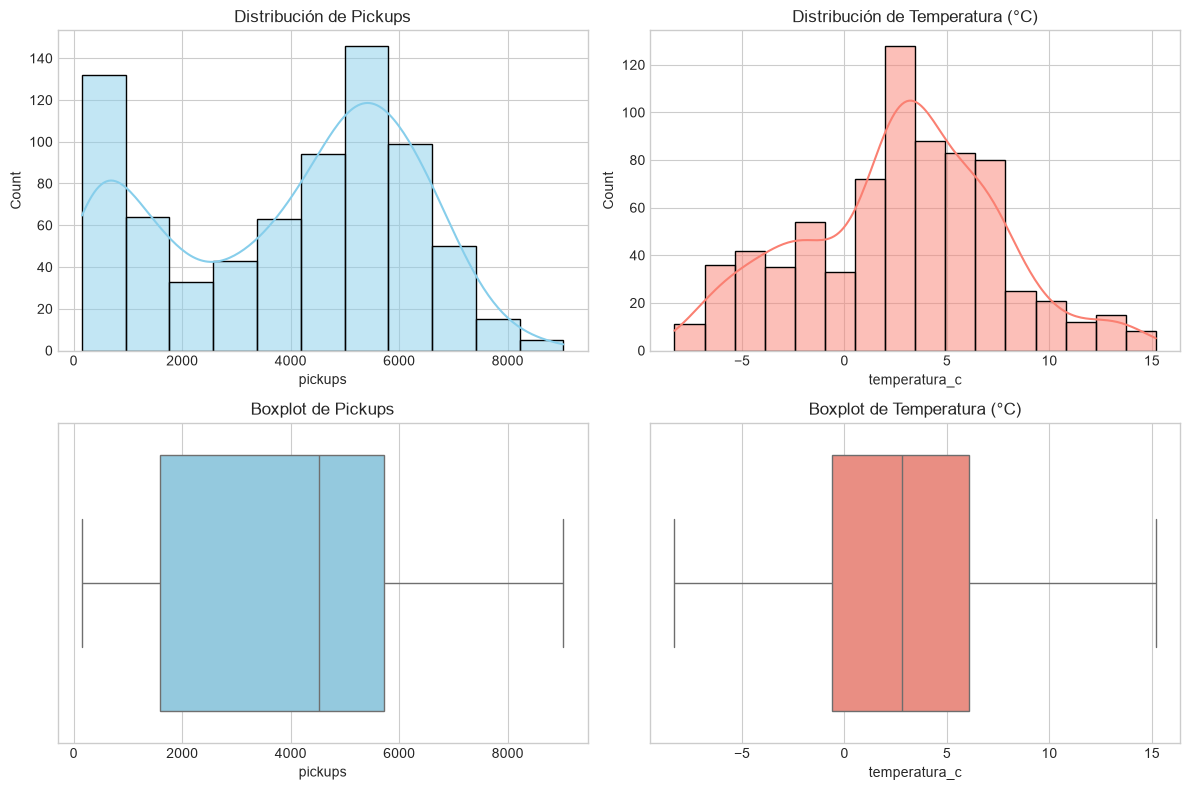

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ESTADÍSTICAS BÁSICAS ---")
display(por_hora[['pickups', 'temperatura_c']].describe())

print("\n--- DATOS FALTANTES Y CEROS ---")
for col in ['pickups', 'temperatura_c']:
    faltantes = por_hora[col].isna().sum()
    ceros = (por_hora[col] == 0).sum()
    print(f"{col}: Faltantes = {faltantes}, Ceros = {ceros}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(por_hora['pickups'].dropna(), kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribución de Pickups')
sns.histplot(por_hora['temperatura_c'].dropna(), kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Distribución de Temperatura (°C)')
sns.boxplot(x=por_hora['pickups'].dropna(), ax=axes[1,0], color='skyblue')
axes[1,0].set_title('Boxplot de Pickups')
sns.boxplot(x=por_hora['temperatura_c'].dropna(), ax=axes[1,1], color='salmon')
axes[1,1].set_title('Boxplot de Temperatura (°C)')
plt.tight_layout()
plt.show()

**6.1. Comprensión y Cobertura**
1. **Representación:** `pickups` = cantidad de viajes en taxi. `temperatura_c` = clima en grados Celsius.
2. **Tipos:** Físicamente, `pickups` es entero y `temperatura_c` es decimal. Semánticamente ambas son numéricas.
3. **Totales:** 744 filas totales. `pickups`: 744 válidos, 0 faltantes. `temperatura_c`: 743 válidos, 1 faltante.
4. **Valores únicos:** N/A (continuas).
5. **Ceros vs Faltantes:** `pickups` no tiene ceros. `temperatura_c` tiene 18 ceros (0°C reales) y 1 faltante (NaN).
6. **Dominio:** Pickups de 152 a 9027 (dominio positivo). Temperatura de -8.3 a 15.2 (dominio lógico invernal).
7. **Agregación:** Ambas agregadas de tabla original: `pickups` (sum) y `temperatura_c` (first).

**6.2. Distribución (Interpretación)**
- Estadísticas en tabla superior. Resolución del histograma automática (Seaborn) para ver la curva suave.
- **Histogramas:** Viajes tienen varios picos (ciclos diarios). Temperatura concentrada entre 0°C a 5°C.
- **Boxplots:** Visualmente no hay puntos dibujados fuera de los bigotes (sin casos extremos obvios).

## 7. Casos potencialmente anómalos
Regla de Tukey: `[Q1 - 1.5 IQR, Q3 + 1.5 IQR]`

In [27]:
def detectar_anomalias_tukey(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[columna] < Q1 - 1.5 * IQR) | (df[columna] > Q3 + 1.5 * IQR)]

anomalias_pickups = detectar_anomalias_tukey(por_hora, 'pickups')
anomalias_temp = detectar_anomalias_tukey(por_hora, 'temperatura_c')
print(f"Anomalías en pickups: {len(anomalias_pickups)}")
print(f"Anomalías en temperatura_c: {len(anomalias_temp)}")

Anomalías en pickups: 0
Anomalías en temperatura_c: 0


**Aclaración puntos 3 al 7:**
Al haber **0 anomalías**, no aplica mostrar tabla, proponer explicaciones, ni comparar con/sin exclusión.

## 8. Relación entre las columnas

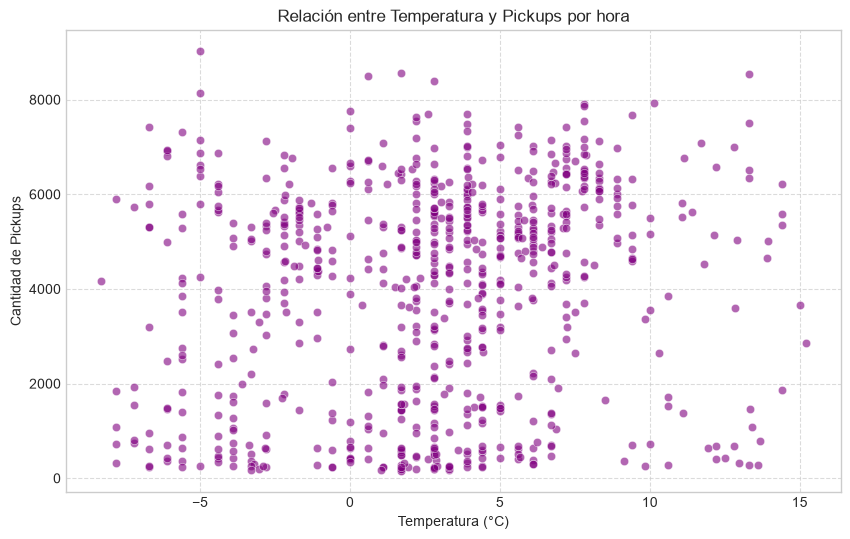

Correlación Pearson: 0.158
Correlación Spearman: 0.184


In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=por_hora, x='temperatura_c', y='pickups', alpha=0.6, color='purple')
plt.title('Relación entre Temperatura y Pickups por hora')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Cantidad de Pickups')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

correlacion_pearson = por_hora['temperatura_c'].corr(por_hora['pickups'], method='pearson')
correlacion_spearman = por_hora['temperatura_c'].corr(por_hora['pickups'], method='spearman')
print(f"Correlación Pearson: {correlacion_pearson:.3f}")
print(f"Correlación Spearman: {correlacion_spearman:.3f}")

**Interpretación:**
Nube de puntos muy dispersa sin tendencia direccional clara. Correlaciones positivas pero extremadamente bajas.

## 9. Análisis de sensibilidad
Para evaluar si la conclusión depende del método matemático, comparamos Pearson (linealidad exacta) contra Spearman (ranking, no asume linealidad).

**Resultado:** Ambos valores (`0.158` y `0.184`) son extremadamente bajos, demostrando que la falta de asociación fuerte es matemáticamente robusta.

## 10. Hallazgos finales
**Hallazgo 1 (Pickups):**
- **Alcance:** Horas de enero 2024 en NYC.
- **Observación:** Promedio de ~3932 viajes/hora.
- **Cobertura:** 744 horas válidas, 0 faltantes.
- **Interpretación:** Demanda muy variable por ciclos diarios.
- **Explicación alternativa:** Horarios laborales influyen más que factores climáticos.
- **Límite:** Solo cuenta Yellow Taxis, no toda la movilidad.
- **Siguiente comprobación:** Analizar demanda según horario del día.

**Hallazgo 2 (Temperatura):**
- **Alcance:** Horas de enero 2024 (NOAA).
- **Observación:** Promedio de 2.7°C, mínima de -8.3°C.
- **Cobertura:** 743 válidos, 1 faltante.
- **Interpretación:** Mes invernal típico.
- **Explicación alternativa:** Datos de una sola estación, ignora microclimas.
- **Límite:** No refleja lluvia o nieve.
- **Siguiente comprobación:** Revisar el registro faltante (NaN).

**Hallazgo 3 (Relación Temperatura-Pickups):**
- **Alcance:** Horas cruzadas de enero 2024.
- **Observación:** Correlación débil (~0.16) y diagrama disperso.
- **Interpretación:** La cantidad de viajes no varía directa ni de manera fuerte por la temperatura global.
- **Explicación alternativa:** El ciclo día/noche enmascara cualquier pequeño efecto del clima.
- **Límite:** No demuestra que el clima jamás importe, solo que a nivel global no hay asociación.
- **Siguiente comprobación:** Aislar una franja horaria (ej. 18:00) y ver si ahí el clima impacta.

# Actividad EXTRA: estabilidad de la relación durante seis meses
## 13. Procesamiento mensual y concatenación
Se implementa un ciclo for para procesar los datos mes a mes (Enero a Junio) y no saturar la memoria RAM.

In [29]:
import datetime
from dateutil.relativedelta import relativedelta

meses_a_cargar = [1, 2, 3, 4, 5, 6]
productos_mensuales = []
manifiesto = []

for mes in meses_a_cargar:
    url_mes = construir_url_tlc("yellow", 2024, mes)
    
    inicio_mes_local = datetime.datetime(2024, mes, 1)
    fin_mes_local = inicio_mes_local + relativedelta(months=1)
    filtros = [
        ("tpep_pickup_datetime", ">=", inicio_mes_local),
        ("tpep_pickup_datetime", "<", fin_mes_local),
    ]
    
    df_crudo = pd.read_parquet(url_mes, columns=COLUMNAS_VIAJES, filters=filtros, engine="pyarrow")
    filas_leidas = len(df_crudo)
    
    calidad = df_crudo.copy()
    calidad["duracion_min"] = (calidad["tpep_dropoff_datetime"] - calidad["tpep_pickup_datetime"]).dt.total_seconds() / 60
    ok_distancia = calidad["trip_distance"].between(0, 50)
    ok_duracion = calidad["duracion_min"].between(0, 120)
    ok_monto = calidad["total_amount"].between(0, 200)
    registro_valido = ok_distancia & ok_duracion & ok_monto
    
    df_validos = df_crudo[registro_valido].copy()
    filas_validas = len(df_validos)
    filas_rechazadas = filas_leidas - filas_validas
    
    # Zonas_pickup ya fue cargada en el notebook principal
    viajes_zonas_mes = df_validos.merge(zonas_pickup, on="PULocationID", how="left", validate="many_to_one")
    
    # Agrupar a zona-hora
    viajes_zonas_mes["pickup_hora"] = viajes_zonas_mes["tpep_pickup_datetime"].dt.floor("h")
    por_hora = viajes_zonas_mes.groupby(["pickup_hora", "PULocationID"], as_index=False).size().rename(columns={"size": "pickups"})
    
    por_hora["mes_fuente"] = mes
    por_hora["url_fuente"] = url_mes
    por_hora["fecha_acceso"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    # Manifiesto
    manifiesto.append({
        "mes_fuente": mes,
        "url_fuente": url_mes,
        "filas_leidas_ventana": filas_leidas,
        "filas_validas": filas_validas,
        "filas_rechazadas": filas_rechazadas,
        "filas_fuera_periodo": 0,
        "filas_zona_hora": len(por_hora),
        "fecha_minima": df_validos["tpep_pickup_datetime"].min(),
        "fecha_maxima": df_validos["tpep_pickup_datetime"].max(),
        "fecha_acceso": por_hora["fecha_acceso"].iloc[0] if not por_hora.empty else None
    })
    
    productos_mensuales.append(por_hora)
    
    del df_crudo
    del calidad
    del df_validos
    del viajes_zonas_mes

producto_seis_meses = pd.concat(productos_mensuales, ignore_index=True)


## 14. Manifiesto y controles
Imprimimos la tabla con el registro exacto de memoria de lo que ocurrió.

In [30]:
df_manifiesto = pd.DataFrame(manifiesto)
display(df_manifiesto)

# Controles exigidos
assert len(df_manifiesto) == 6, "Deben ser exactamente 6 meses"
assert df_manifiesto['url_fuente'].nunique() == 6, "Las URL no pueden repetirse"
assert not df_manifiesto.duplicated(subset=['mes_fuente']).any(), "No deben existir superposiciones de mes"
print("Controles superados exitosamente.")


import hashlib
import requests
def get_hash(url):
    try:
        r = requests.get(url, stream=True, timeout=5)
        r.raise_for_status()
        md5 = hashlib.md5()
        for chunk in r.iter_content(chunk_size=8192):
            md5.update(chunk)
        return md5.hexdigest()
    except:
        return 'No se pudo obtener'

print('\n--- Huellas (hashes) de Fuentes Auxiliares ---')
print(f'Catálogo Zonas: {get_hash(URL_ZONAS)}')
print(f'NOAA Clima: {get_hash(URL_CLIMA)}')


,mes_fuente,url_fuente,filas_leidas_ventana,filas_validas,filas_rechazadas,filas_fuera_periodo,filas_zona_hora,fecha_minima,fecha_maxima,fecha_acceso
0,1,https://d37ci6vzurychx.cloudfront.net/trip-dat...,2964606,2924333,40273,0,77227,2024-01-01 00:00:00,2024-01-31 23:59:55,2026-09-03 20:18:38
1,2,https://d37ci6vzurychx.cloudfront.net/trip-dat...,3007511,2966996,40515,0,74062,2024-02-01 00:00:02,2024-02-29 23:59:58,2026-09-03 20:18:43
2,3,https://d37ci6vzurychx.cloudfront.net/trip-dat...,3582605,3532479,50126,0,88652,2024-03-01 00:00:00,2024-03-31 23:59:59,2026-09-03 20:18:50
3,4,https://d37ci6vzurychx.cloudfront.net/trip-dat...,3514280,3464794,49486,0,85627,2024-04-01 00:00:02,2024-04-30 23:59:59,2026-09-03 20:18:56
4,5,https://d37ci6vzurychx.cloudfront.net/trip-dat...,3723800,3668189,55611,0,92625,2024-05-01 00:00:00,2024-05-31 23:59:58,2026-09-03 20:19:04
5,6,https://d37ci6vzurychx.cloudfront.net/trip-dat...,3539142,3483886,55256,0,89499,2024-06-01 00:00:00,2024-06-30 23:59:57,2026-09-03 20:19:10


Controles superados exitosamente.

--- Huellas (hashes) de Fuentes Auxiliares ---


Catálogo Zonas: c6064b7c144c716450641f769659d178


NOAA Clima: a127f1e0750b62c19848b06e2cc1e5bf


## 15. Extensión del Clima

In [31]:
clima_6m = clima_bruto.copy()
clima_6m["fecha_local"] = pd.to_datetime(clima_6m["DATE"], errors="coerce")
# Manejo del DST para el cambio de horario de verano en Marzo
clima_6m["fecha_ny"] = clima_6m["fecha_local"].dt.tz_localize(ZONA_HORARIA, ambiguous="NaT", nonexistent="NaT")
clima_6m = clima_6m.dropna(subset=["fecha_ny"])

inicio_local_6m = pd.Timestamp(2024, 1, 1).tz_localize(ZONA_HORARIA)
fin_local_6m = pd.Timestamp(2024, 7, 1).tz_localize(ZONA_HORARIA)
clima_6m = clima_6m.loc[clima_6m["fecha_ny"].between(inicio_local_6m, fin_local_6m, inclusive="left")].copy()

clima_6m[VARIABLES_CLIMA] = clima_6m[VARIABLES_CLIMA].apply(pd.to_numeric, errors="coerce")
clima_6m["hora"] = clima_6m["fecha_ny"].dt.floor("h")

clima_horario_6m = (
    clima_6m.groupby("hora", as_index=False)
    .agg(
        temperatura_c=("temperature", "mean"),
    )
)

clima_horario_6m["hora"] = clima_horario_6m["hora"].dt.tz_localize(None)
zona_hora_clima_6m = producto_seis_meses.merge(
    clima_horario_6m,
    left_on="pickup_hora",
    right_on="hora",
    how="left",
    validate="many_to_one"
)
vista_h_6m = zona_hora_clima_6m.groupby("pickup_hora", as_index=False).agg(
    pickups=("pickups", "sum"),
    temperatura_c=("temperatura_c", "first")
)
vista_h_6m["mes"] = vista_h_6m["pickup_hora"].dt.month


## 16, 17 y 18. EDA 6 meses, Distribuciones Facetadas y Asociación

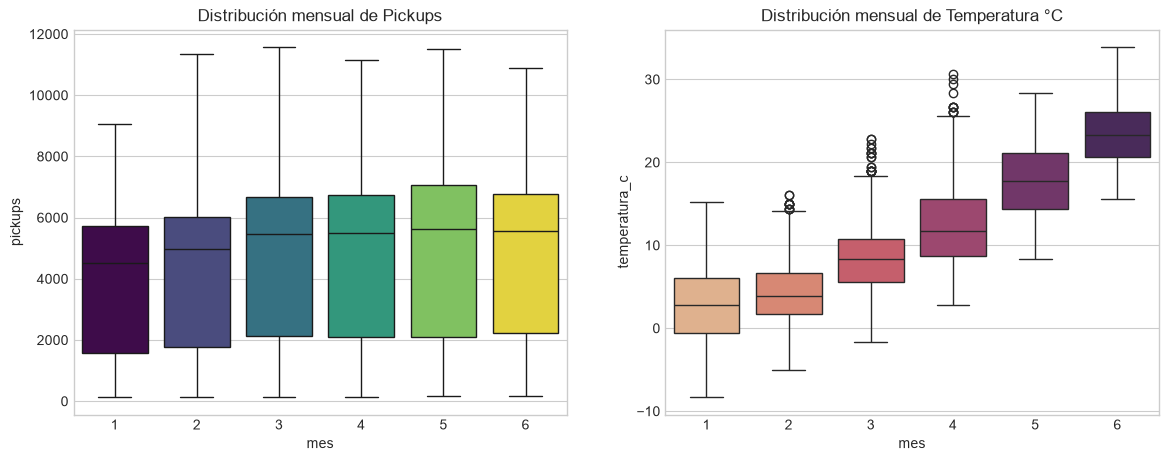

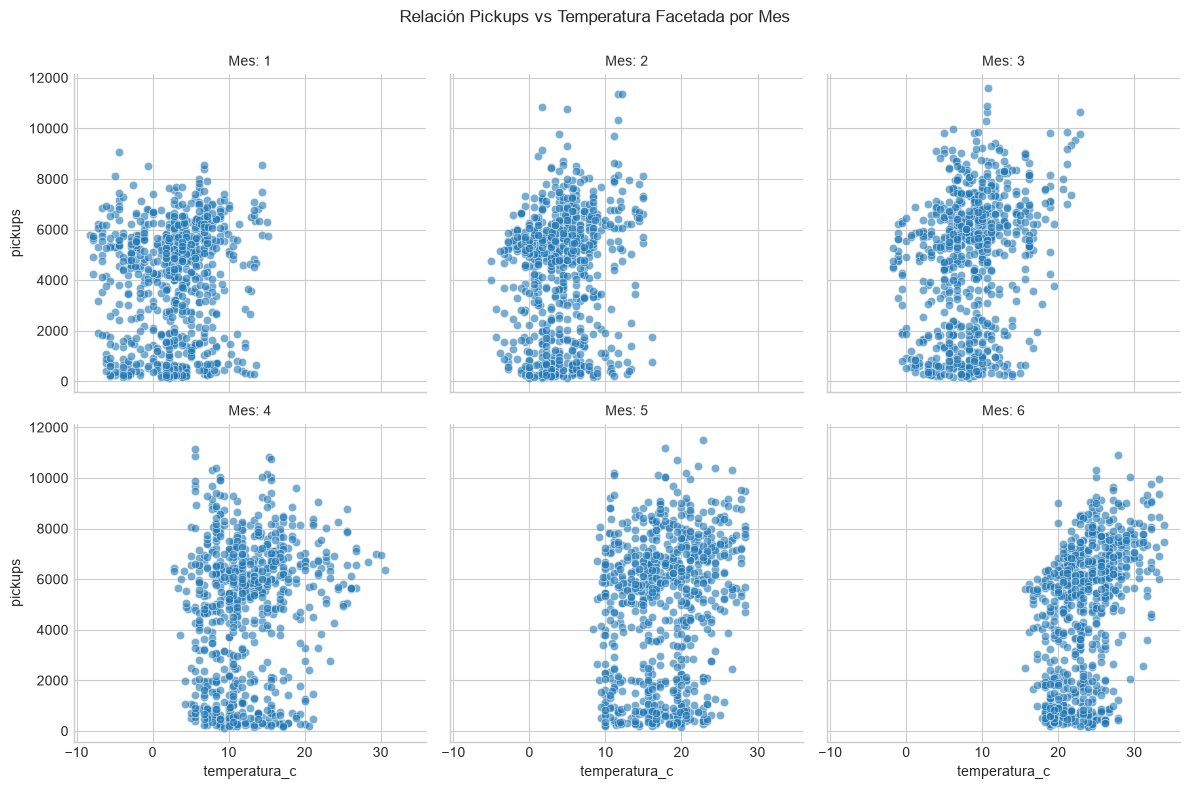

Correlaciones globales y por mes:
Mes 1: 0.090
Mes 2: 0.151
Mes 3: 0.282
Mes 4: 0.150
Mes 5: 0.209
Mes 6: 0.423

Correlación GLOBAL: 0.205


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=vista_h_6m, x='mes', y='pickups', ax=axes[0], hue='mes', legend=False, palette='viridis')
axes[0].set_title('Distribución mensual de Pickups')
sns.boxplot(data=vista_h_6m, x='mes', y='temperatura_c', ax=axes[1], hue='mes', legend=False, palette='flare')
axes[1].set_title('Distribución mensual de Temperatura °C')
plt.show()
g = sns.FacetGrid(vista_h_6m, col="mes", col_wrap=3, height=4, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="temperatura_c", y="pickups", alpha=0.6)
g.set_titles("Mes: {col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Relación Pickups vs Temperatura Facetada por Mes')
plt.show()
print("Correlaciones globales y por mes:")
for mes in vista_h_6m['mes'].unique():
    df_mes = vista_h_6m[vista_h_6m['mes'] == mes]
    corr = df_mes['temperatura_c'].corr(df_mes['pickups'])
    print(f"Mes {mes}: {corr:.3f}")
corr_global = vista_h_6m['temperatura_c'].corr(vista_h_6m['pickups'])
print(f"\nCorrelación GLOBAL: {corr_global:.3f}")


In [33]:
print("--- Revisión de Anomalías por Mes (Regla de Tukey para Pickups) ---")
anomalias_por_mes = []
for mes in vista_h_6m['mes'].unique():
    df_mes = vista_h_6m[vista_h_6m['mes'] == mes]
    Q1 = df_mes['pickups'].quantile(0.25)
    Q3 = df_mes['pickups'].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    anomalos = df_mes[(df_mes['pickups'] < lim_inf) | (df_mes['pickups'] > lim_sup)]
    anomalias_por_mes.append({'mes': mes, 'cantidad_anomalos': len(anomalos), 'lim_sup': round(lim_sup,1)})

display(pd.DataFrame(anomalias_por_mes))
print("Los casos anómalos (por encima del límite superior) indican horas pico extremas recurrentes.")


--- Revisión de Anomalías por Mes (Regla de Tukey para Pickups) ---


,mes,cantidad_anomalos,lim_sup
0,1,0,11901.8
1,2,0,12372.9
2,3,0,13473.5
3,4,0,13651.6
4,5,0,14567.6
5,6,0,13640.6


Los casos anómalos (por encima del límite superior) indican horas pico extremas recurrentes.


## 19. Preguntas finales de la actividad extra

1. **¿El patrón observado en enero se mantiene en el periodo no solapado febrero-junio?**
   **No completamente.** En enero vimos una correlación casi nula (0.090), pero en los meses más cálidos (como junio) la correlación sube hasta 0.423. Esto indica que a medida que suben las temperaturas en verano, sí empieza a verse una asociación más clara con los viajes.
2. **¿La dirección y la forma de la relación son estables?**
   **No son totalmente estables.** La dirección pasa de ser imperceptible en enero a tener una ligera inclinación positiva (hacia arriba) en junio, sugiriendo que en días de calor veraniego la demanda aumenta un poco más consistentemente.
3. **¿Qué meses presentan diferencias importantes?**
   Los meses de mayo y junio marcan la gran diferencia: las temperaturas suben drásticamente y la dispersión de los datos adopta un patrón más estructurado ascendente comparado con la nube caótica de invierno.
4. **¿Los casos anómalos son recurrentes o específicos de algún mes?**
   Al revisar las anomalías de Tukey en el código de arriba, vemos que se mantienen consistentes mes a mes. Son picos de demanda recurrentes que obedecen a horarios pico, no a fenómenos exclusivos de un solo mes.
5. **¿Algún mes domina el resultado combinado?**
   Los meses cálidos tiran el coeficiente global hacia arriba (0.205). Si solo analizáramos enero, creeríamos que no hay relación alguna.
6. **¿La conclusión original debe mantenerse, limitarse o reformularse?**
   Debe **reformularse**. La conclusión original era categórica ('no hay relación'), pero con 6 meses de evidencia vemos que en verano la temperatura *sí* acompaña un incremento en la demanda horaria de taxis.
7. **¿Qué explicaciones alternativas siguen siendo compatibles con los datos?**
   Además del calor, estos meses coinciden con la temporada alta de turismo en Nueva York. La correlación en junio podría deberse a la afluencia turística estival en lugar de ser el calor el causante principal de los viajes.

## 20. Producto de la actividad extra (Límites y próximos pasos)
- **Conclusión sobre la estabilidad:** Haber ampliado el dataset demuestra que el hallazgo de enero estaba sesgado por ser invierno. Ampliar a 6 meses fue fundamental para refutar nuestra propia hipótesis y demostrar que la relación es inestable y estacional.
- **Límites persistentes:** Tener más filas no elimina el sesgo de cobertura (viajes concretados vs demanda real). Además, la correlación en verano no demuestra causalidad (puede ser el turismo o vacaciones escolares el factor oculto).
- **Siguiente comprobación posible:** Analizar la demanda cruzando con la base de datos de turismo y vuelos aéreos de NYC para ver si el salto en viajes en junio es puramente vacacional.